## 4.3 위상 양자 부호(표면 부호) 맥락의 양자 오류 정정 (Surface Code)

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit.quantum_info import Statevector, random_statevector
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# AerSimulator 초기화
simulator = AerSimulator()

In [3]:
# 9개 큐비트 + 3개 보조 큐비트로 표면 부호 양자 회로 생성
qc = QuantumCircuit(9, 3)

In [4]:
# 논리 큐비트 인코딩을 흉내 내기 위한 무작위 초기 상태 생성
initial_state = random_statevector(2)
qc.initialize(initial_state, 0)

In [5]:
# 오류 검출 준비를 위해 하다마드 게이트 적용
for qubit in range(1, 9):
    qc.h(qubit)

In [6]:
# 안정자를 측정해 오류 검출
qc.cx(1, 0)
qc.cx(4, 0)
qc.cx(2, 1)
qc.cx(5, 1)
qc.cx(4, 3)
qc.cx(7, 3)
qc.cx(5, 4)
qc.cx(8, 4)
qc.cx(7, 6)
qc.cx(0, 6)
qc.cx(8, 7)
qc.cx(1, 7)

In [7]:
# 오류 정정을 위해 마지막 하다마드 게이트 라운드 수행
for qubit in range(1, 9):
    qc.h(qubit)

In [8]:
# 보조 큐비트를 측정해 오류 검출
qc.measure([0, 1, 2], [0, 1, 2])

In [9]:
# **회로 끝에서 상태벡터 저장**
qc.save_statevector()

In [10]:
# 시뮬레이터용으로 회로 트랜스파일
compiled_circuit = transpile(qc, simulator)

Quantum Circuit before compilation:


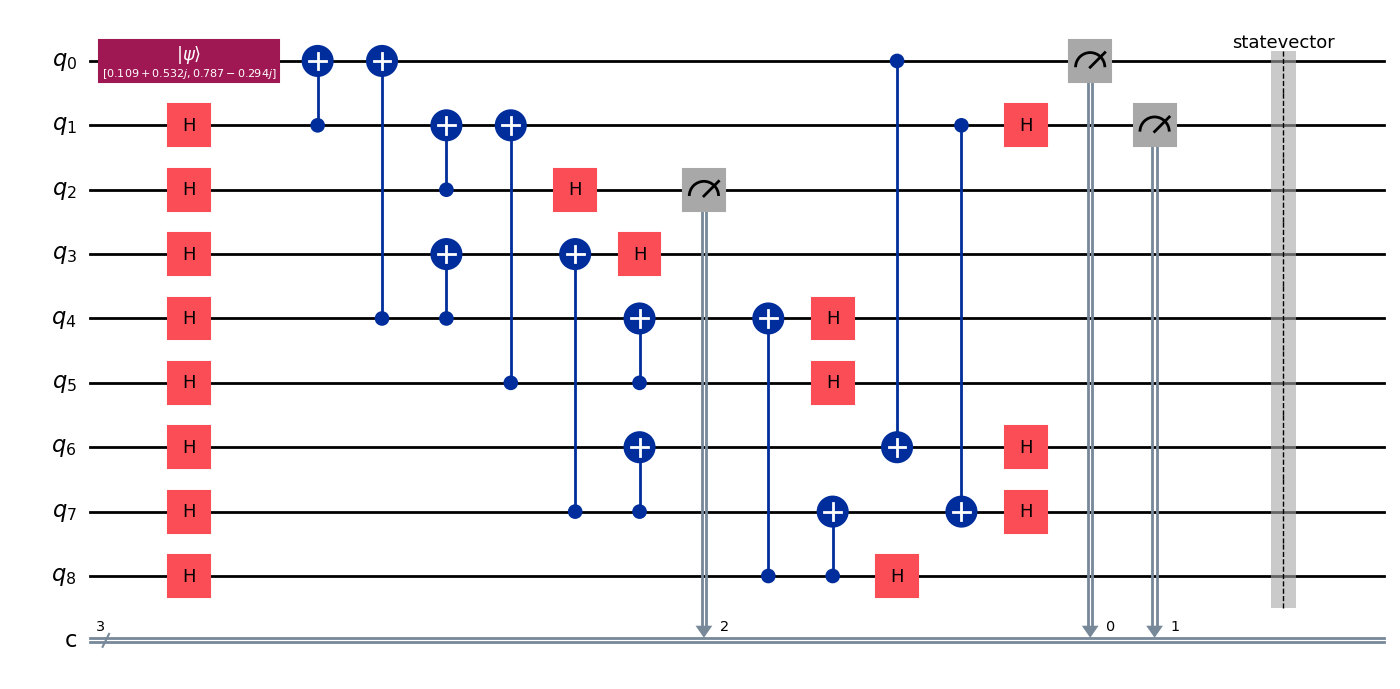

In [11]:
# 컴파일 전 양자 회로 그리기
print("Quantum Circuit before compilation:")
qc.draw('mpl')
plt.show()


Quantum Circuit after compilation:


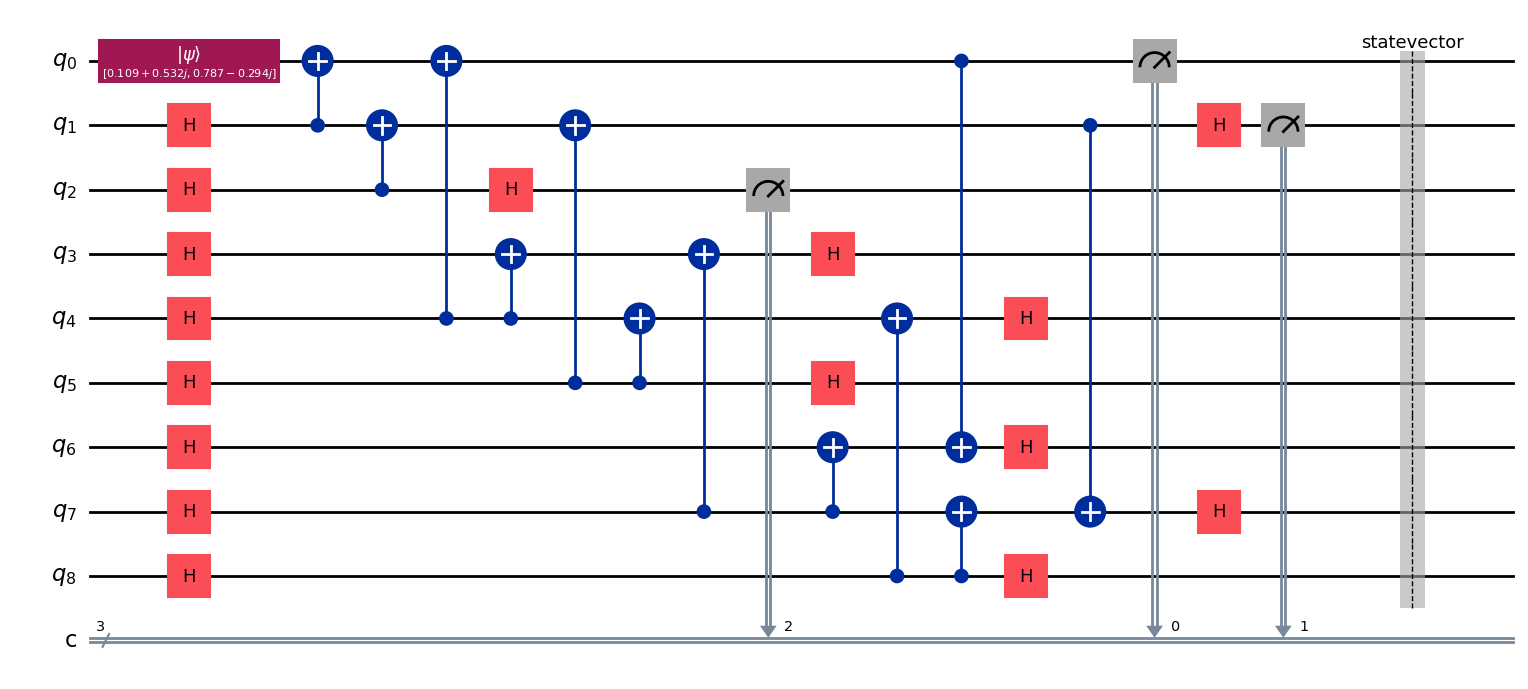

In [12]:
# 컴파일 후 양자 회로 그리기
print("\nQuantum Circuit after compilation:")
compiled_circuit.draw('mpl')
plt.show()

In [13]:
# 회로 실행
result = simulator.run(compiled_circuit).result()

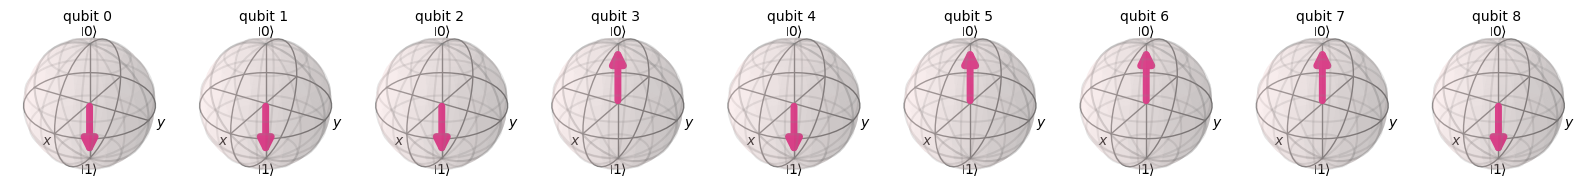

In [14]:
# 상태벡터를 추출해 블로흐 구로 그리기
statevector = Statevector(result.get_statevector())
plot_bloch_multivector(statevector)
plt.show()

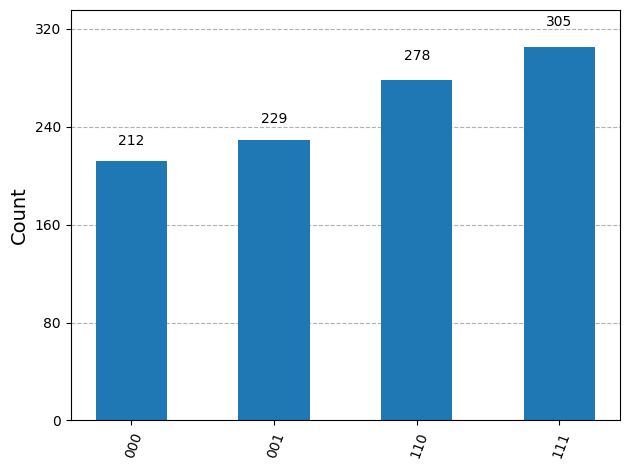

In [15]:
# 카운트를 추출해 측정 결과를 히스토그램으로 그리기
counts = result.get_counts()
plot_histogram(counts)
plt.show()